In [7]:
!mamba install pandas

/bin/bash: line 1: mamba: command not found


In [8]:
import pandas as pd
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")
datafile.groupby('group').describe()

A                                                extra        ...  \
      count  mean      std   min    25%   50%    75%   max count  mean  ...   
group                                                                   ...   
1      10.0   5.5  3.02765   1.0   3.25   5.5   7.75  10.0  10.0  0.75  ...   
2      10.0  15.5  3.02765  11.0  13.25  15.5  17.75  20.0  10.0  2.33  ...   

                    ID                                            
        75%  max count mean      std  min   25%  50%   75%   max  
group                                                             
1      1.70  3.7  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  
2      4.15  5.5  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  

[2 rows x 24 columns]

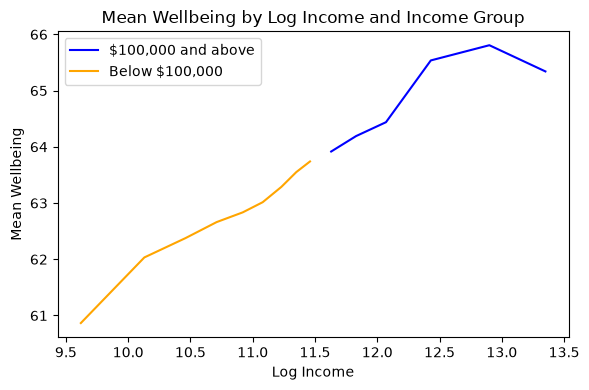

In [9]:
import pandas as pd, numpy as np 
import matplotlib.pyplot as plt 
source=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/Income2023.csv")
# Aggregate at each observed income value for a readable reproduction of the fitted relationships.
figure_2 = (source.groupby(['income_above_100','income','log_income'], as_index=False)
            .agg(mean_wellbeing=('wellbeing','mean'), n=('wellbeing','size')))
figure_2['income_group'] = np.where(figure_2['income_above_100'].eq(1), '$100,000 and above', 'Below $100,000')
figure_2 = figure_2.sort_values(['income_group','log_income'])
plt.figure(figsize=(6, 4))
plt.plot(figure_2.query("income_group == '$100,000 and above'")['log_income'],
         figure_2.query("income_group == '$100,000 and above'")['mean_wellbeing'], label='$100,000 and above', color='blue')
plt.plot(figure_2.query("income_group == 'Below $100,000'")['log_income'],
         figure_2.query("income_group == 'Below $100,000'")['mean_wellbeing'], label='Below $100,000', color='orange')
plt.xlabel('Log Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Log Income and Income Group')
plt.legend()
plt.tight_layout()
#plt.savefig("C:\\2023_income_wellbeing.png", dpi=300)
plt.show()


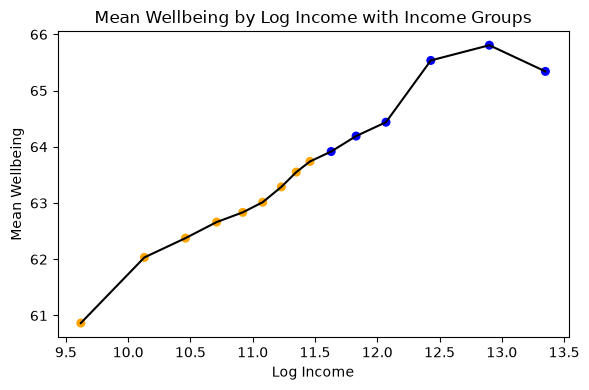

In [10]:
figure_2 = figure_2.sort_values('log_income')

plt.figure(figsize=(6, 4))
plt.plot(figure_2['log_income'], figure_2['mean_wellbeing'],
         color='black', linewidth=1.5)

# Optional: add colored points for groups
plt.scatter(figure_2['log_income'], figure_2['mean_wellbeing'],
            c=figure_2['income_group'].map({
                '$100,000 and above': 'blue',
                'Below $100,000': 'orange'
            }),
            s=30)
plt.xlabel('Log Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Log Income with Income Groups')
plt.tight_layout()
#plt.savefig("C:\\income_wellbeing1.png", dpi=300)
plt.show()

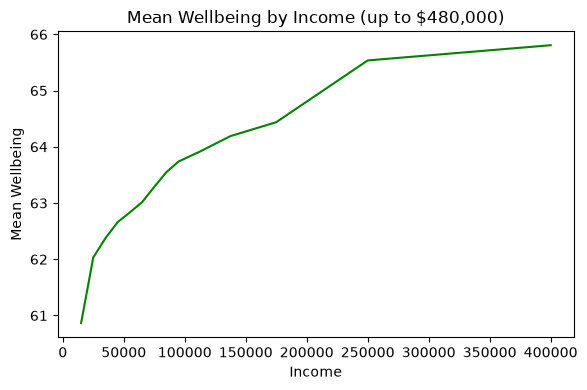

In [11]:
plot_data = (figure_2.loc[figure_2['income'] <= 480000]
             .groupby('income', as_index=False)
             .agg(mean_wellbeing=('mean_wellbeing','mean'), n=('n','sum'))
             .sort_values('income'))
plt.figure(figsize=(6, 4))
plt.plot(plot_data['income'], plot_data['mean_wellbeing'], color='green')
plt.xlabel('Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Income (up to $480,000)')
plt.tight_layout()
plt.show()

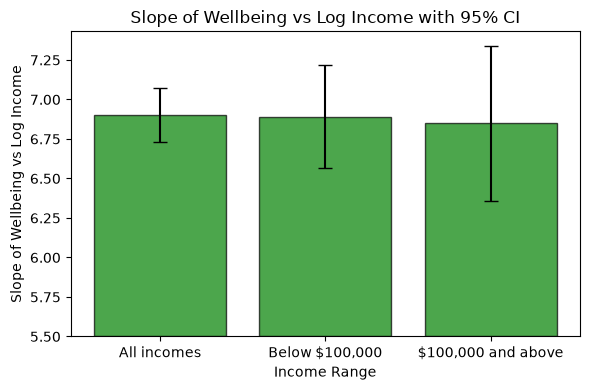

In [12]:
rows=[]
for label, d in [('All incomes', source), ('Below $100,000', source[source['income_above_100']==0]), ('$100,000 and above', source[source['income_above_100']==1])]:
    x=d['log_income'].to_numpy(); y=d['wellbeing'].to_numpy()
    X=np.column_stack([np.ones(len(d)), x])
    coef=np.linalg.lstsq(X,y,rcond=None)[0]
    residual=y-X@coef
    se=np.sqrt((residual@residual/(len(d)-2))*np.linalg.inv(X.T@X)[1,1])
    rows.append({'income_range':label,'slope':coef[1],'standard_error':se,'n':len(d),'r_squared':1-(residual@residual)/((y-y.mean())@(y-y.mean()))})
table_1=pd.DataFrame(rows)
table_1['ci_lower']=table_1['slope']-1.96*table_1['standard_error']
table_1['ci_upper']=table_1['slope']+1.96*table_1['standard_error']
plt.figure(figsize=(6, 4))
plt.bar(table_1['income_range'], bottom=5.5, height=table_1['slope'],
                 yerr=1.96*table_1['standard_error'], capsize=5, color='green', alpha=0.7, edgecolor='black')
#plt.errorbar(table_1['income_range'], table_1['slope'],
#                yerr=1.96*table_1['standard_error'], fmt='o', capsize=5, color='purple')
plt.xlabel('Income Range')
plt.ylabel('Slope of Wellbeing vs Log Income')
plt.title('Slope of Wellbeing vs Log Income with 95% CI')
plt.tight_layout()
plt.show()


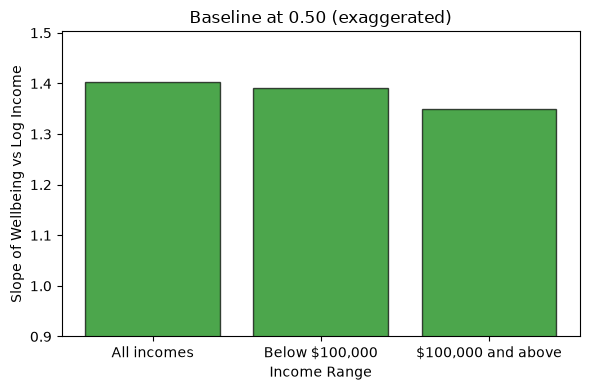

In [13]:
plt.figure(figsize=(6,4))
plt.bar(table_1['income_range'], table_1['slope'],
        capsize=5, color='green', alpha=0.7, edgecolor='black')
plt.ylim(0.9, table_1['slope'].max() + .1)
plt.title("Baseline at 0.50 (exaggerated)")
plt.xlabel("Income Range")
plt.ylabel("Slope of Wellbeing vs Log Income")
plt.tight_layout()
plt.show()

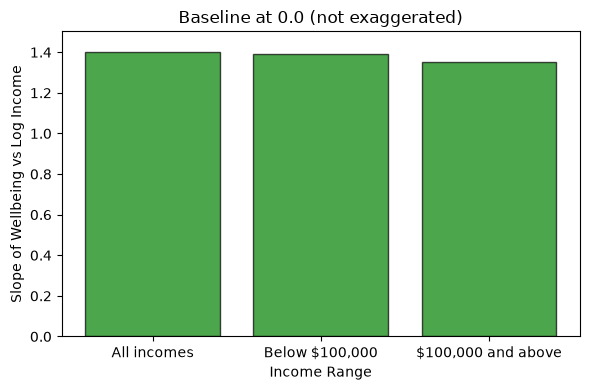

In [14]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(table_1['income_range'], table_1['slope'],
        capsize=5, color='green', alpha=0.7, edgecolor='black')
plt.ylim(0.0, table_1['slope'].max() + .1)
plt.title("Baseline at 0.0 (not exaggerated)")
plt.xlabel("Income Range")
plt.ylabel("Slope of Wellbeing vs Log Income")
plt.tight_layout()
plt.show()


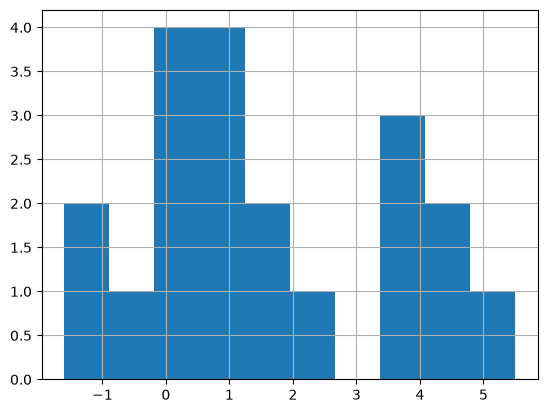

In [15]:
datafile["extra"].hist()
plt.show()

<Axes: ylabel='Density'>

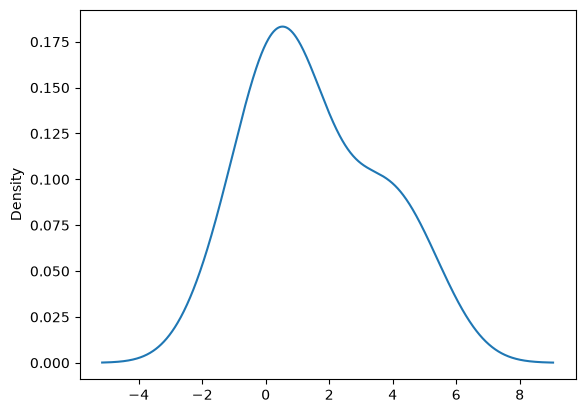

In [16]:
datafile["extra"].plot(kind="density")

<Axes: >

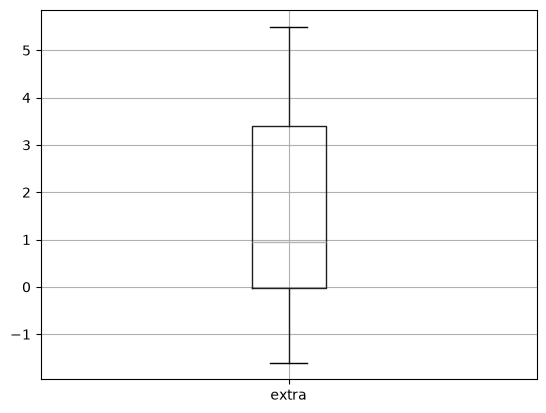

In [17]:
datafile.boxplot(column="extra")

<Axes: ylabel='Frequency'>

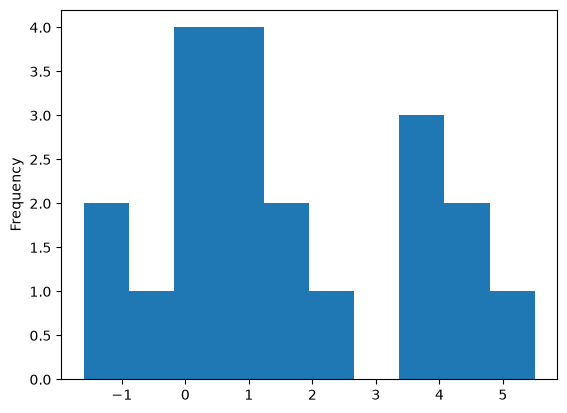

In [18]:
# Histogram
datafile["extra"].plot(kind="hist")

<Axes: ylabel='Density'>

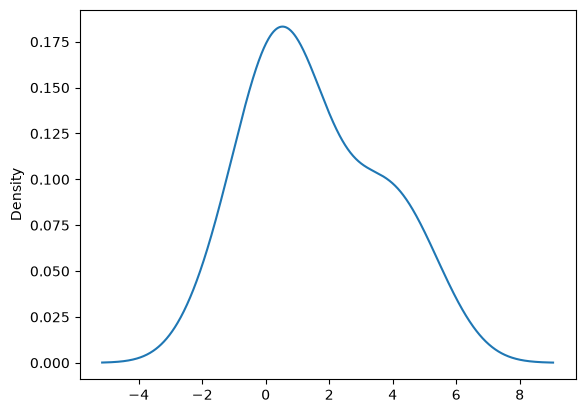

In [23]:
# Density curve
datafile["extra"].plot.kde()

<Axes: >

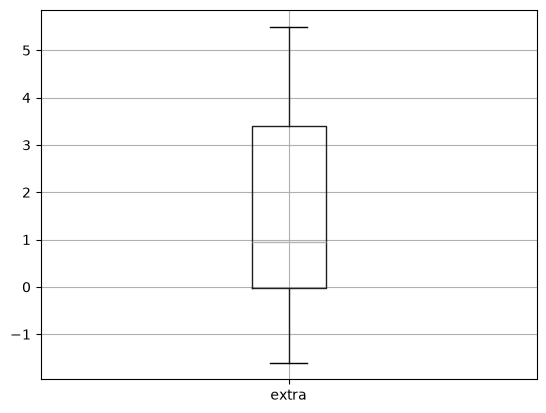

In [20]:
# Boxplot
datafile.boxplot(column="extra")

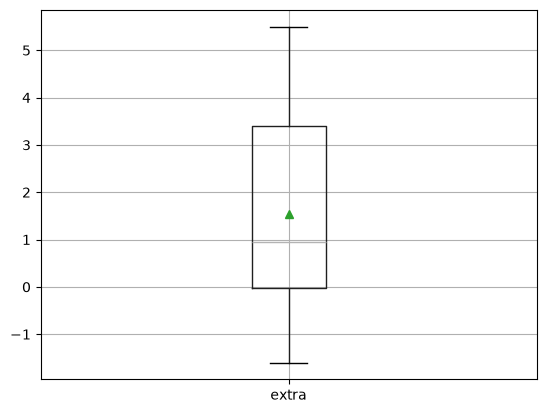

In [21]:
datafile.boxplot(
    column="extra",
    showmeans=True
)
plt.show()

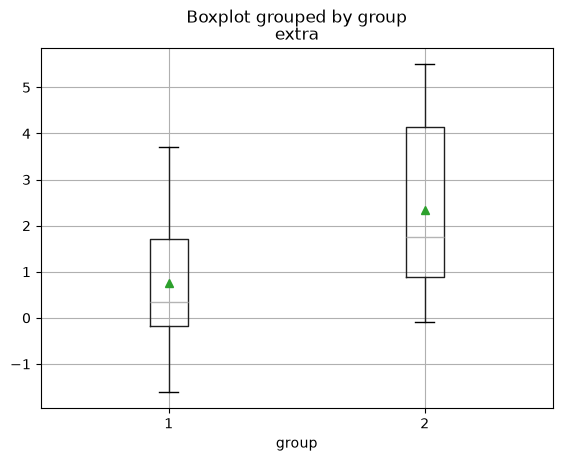

In [22]:
datafile.boxplot(column="extra", by="group", showmeans=True)
plt.show()